# 📘 Notebook – Etapa Descritiva (base para Análise Preditiva)

## Análise Exploratória e Qualidade dos Dados (EDA)

Esta seção descreve a estrutura e a qualidade do conjunto de dados utilizados no estudo.  
**Fonte:** [ Lesões no Futebol Europeu 2020–2025 (Kaggle) ]( https://www.kaggle.com/datasets/sananmuzaffarov/european-football-injuries-2020-2025 )  
 **Licença:** CC BY-SA 4.0 — https://creativecommons.org/licenses/by-sa/4.0/

---

### 1) Importações e carregamento do conjunto de dados

In [1]:
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

## 2) Visão geral

### Coleta de Dados do Kaggle

In [2]:
# Acessando dataset European Football Injuries (2020-2025)
sys.path.append(os.path.abspath(os.path.join('..', '..')))

In [3]:
from src.data_loader import load_injuries_data

df_injuries = load_injuries_data()

c:\Users\beatr\pmv-si-2026-1-pe7-t1-g3-analytics_lesao_futebol\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:

print ("Linhas:", df_injuries.shape[0])
print ("Colunas:", df_injuries.shape[1])
print ("\nNome das colunas:", list(df_injuries.columns))

Linhas: 15603
Colunas: 11

Nome das colunas: ['Season', 'Injury', 'Days', 'Games missed', 'injury_from_parsed', 'injury_until_parsed', 'player_name', 'player_age', 'player_position', 'club', 'league']


In [5]:
print(df_injuries.dtypes)

Season                   str
Injury                   str
Days                     str
Games missed           int64
injury_from_parsed       str
injury_until_parsed      str
player_name              str
player_age             int64
player_position          str
club                     str
league                   str
dtype: object


In [6]:
df_injuries.head()

,Season,Injury,Days,Games missed,injury_from_parsed,injury_until_parsed,player_name,player_age,player_position,club,league
0,20/21,Syndesmosis ligament tear,43 days,9,1/28/2021,3/11/2021,Alexander Nübel,24,Goalkeeper,Bayern Munich,Bundesliga
1,20/21,Knee injury,37 days,6,3/7/2021,4/12/2021,Ron-Thorben Hoffmann,22,Goalkeeper,Bayern Munich,Bundesliga
2,20/21,Corona virus,21 days,4,2/17/2021,3/9/2021,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
3,20/21,bruise,8 days,2,11/6/2020,11/13/2020,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
4,20/21,Ligament injury,22 days,2,7/26/2020,8/16/2020,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga


In [7]:
df_injuries.tail()

,Season,Injury,Days,Games missed,injury_from_parsed,injury_until_parsed,player_name,player_age,player_position,club,league
15598,24/25,Calf muscle tear,22 days,2,3/14/2025,4/4/2025,Taty Castellanos,27,Forward,Lazio,Serie A
15599,24/25,Adductor injury,25 days,6,2/15/2025,3/11/2025,Taty Castellanos,27,Forward,Lazio,Serie A
15600,24/25,Adductor injury,9 days,2,9/16/2024,9/24/2024,Taty Castellanos,27,Forward,Lazio,Serie A
15601,24/25,Ankle injury,6 days,1,2/9/2025,2/14/2025,Boulaye Dia,28,Forward,Lazio,Serie A
15602,24/25,Ankle injury,10 days,3,11/28/2024,12/7/2024,Boulaye Dia,28,Forward,Lazio,Serie A


O dataset contém registros de eventos de lesão/indisponibilidade de jogadores profissionais
de futebol nas cinco principais ligas europeias: **Bundesliga, Premier League, La Liga,
Ligue 1 e Série A**. Cada linha representa um evento único de afastamento associado a um
jogador, com informações de contexto (clube e liga), características do atleta (idade e
posição) e impacto esportivo (dias afastados e jogos perdidos).
  - **
Total de registros:** 15.603 - **   
Total de atributos: ** 11 - ** Temporados presentes   
: ** 20/21 , 21/22 , 22/23 , 23/24 , 24/25

In [8]:
dicionario = pd.DataFrame({
    "Atributo": [
        "Season" , "Injury" , "Days" , "Games Missed" , "injury_from_parsed" ,
        "injury_until_parsed" , "player_name" , "player_age" , "player_position" ,
        "club" , "league"
    ],
    "Descricao": [
        "Temporada da ocorrência" ,
         "Tipo/descrição da lesão ou condição" ,
         "Duração do afastamento (texto, ex: '43 dias')" ,
         "Número de partidas perdidas" ,
         "Data de início do afastamento" ,
         "Data de fim do afastamento" ,
         "Nome do jogador" ,
         "Idade do jogador no evento" ,
         "Posição tática do jogador" ,
         "Clube do jogador" ,
         "Liga associada ao clube"
    ],
    "Tipo (arquivo)": [
        "texto" , "texto" , "texto" , "inteiro" , "texto (dados)" ,
        "texto (dados)" , "texto" , "inteiro" , "texto" , "texto" ,
        "texto"
    ],
    "Unidade/Formato": [
        "—" , "—" , "dias" , "jogos" , "M/D/YYYY" , "M/D/YYYY" ,
        "—" , "anos" , "—" , "—" , "—"
    ],
    "Exemplos": [
        "20/21, 24/25",
        "Lesão no tendão da coxa, lesão no joelho",
        "43 dias, 8 dias" ,
         "9, 2, 145" ,
         "28/01/2021" ,
         "11/03/2021" ,
         "Benjamin Pavard" ,
         "19, 25, 43" ,
         "Goleiro, Zagueiro Central" ,
         "Bayern de Munique" ,
          "Bundesliga, Seria A"
    ]
})

print(dicionario.to_string(index=False))

           Atributo                                     Descricao Tipo (arquivo) Unidade/Formato                                 Exemplos
             Season                       Temporada da ocorrência          texto               —                             20/21, 24/25
             Injury           Tipo/descrição da lesão ou condição          texto               — Lesão no tendão da coxa, lesão no joelho
               Days Duração do afastamento (texto, ex: '43 dias')          texto            dias                          43 dias, 8 dias
       Games Missed                   Número de partidas perdidas        inteiro           jogos                                9, 2, 145
 injury_from_parsed                 Data de início do afastamento  texto (dados)        M/D/YYYY                               28/01/2021
injury_until_parsed                    Data de fim do afastamento  texto (dados)        M/D/YYYY                               11/03/2021
        player_name               

In [9]:
df_injuries = df_injuries.rename(columns={
    "Season": "temporada",
    "Injury": "tipo_lesao",
    "Days": "duracao_dias",
    "Games missed": "jogos_perdidos",
    "injury_from_parsed": "data_inicio_lesao",
    "injury_until_parsed": "data_fim_lesao",
    "player_name": "jogador",
    "player_age": "idade",
    "player_position": "posicao",
    "club": "clube",
    "league": "liga",

})

Para uma anális mais didática, realizamos a tradução das colunas do dataset para pt_BR

In [10]:
# Lista quantidade de linhas e coculas

print(f'''
    Colunas: {len(df_injuries.columns)} - {df_injuries.columns.values}
  ''')


    Colunas: 11 - <StringArray>
[        'temporada',        'tipo_lesao',      'duracao_dias',
    'jogos_perdidos', 'data_inicio_lesao',    'data_fim_lesao',
           'jogador',             'idade',           'posicao',
             'clube',              'liga']
Length: 11, dtype: str
  


## 3) Dados ausentes

In [11]:
missing = df_injuries.isna().sum()
print("\nMissing por coluna:")
print(missing)


Missing por coluna:
temporada            0
tipo_lesao           0
duracao_dias         0
jogos_perdidos       0
data_inicio_lesao    0
data_fim_lesao       0
jogador              0
idade                0
posicao              0
clube                0
liga                 0
dtype: int64


Não foram encontrados valores ausentes em nenhuma das 11 colunas do conjunto de dados
(** 0 % de dados faltantes**). O conjunto de dados está completamente preenchido, o que
elimina a necessidade de imputação ou remoção de registros nesta etapa.

## 4) Duplicatas


In [12]:
dup_count = df_injuries.duplicated().sum()
print("\nDuplicatas exatas (linhas idênticas):", dup_count)


Duplicatas exatas (linhas idênticas): 0


Não foram identificadas duplicatas exatas de linha (** 0 registros duplicados**).
Cada observação representa um evento de afastamento distinto, garantindo a
integridade dos registros para análises longitudinais.

### 5) Consistência temporal e coerência entre variáveis

In [13]:
# Converter dias para numérico
days_num = df_injuries['duracao_dias'].astype(str).str.extract(r"(\d+)")[0].astype(int)
print("\nDura das lesões (dias) - min/max:", np.nanmin(days_num), "e", np.nanmax(days_num))

# Datas
from_dt = pd.to_datetime(df_injuries['data_inicio_lesao'], errors="coerce")
until_dt = pd.to_datetime(df_injuries['data_fim_lesao'], errors="coerce")

print("\nFalhas de parsing - data_inicio_lesao:", from_dt.isna().sum())
print("\nFalhas de parsing - data_fim_lesao:", until_dt.isna().sum())

print("\nPeríodo (datas):")
print("Min data_inicio_lesao:", from_dt.min())
print("Max data_fim_lesao:", until_dt.max())

# Inconsistência: fim antes do início
until_before_from = ((~from_dt.isna()) & (~until_dt.isna()) & (until_dt < from_dt)).sum()
print("\nCasos com until < from:", until_before_from)

# Coerência: Days vs (until - from)
duration_from_dates = (until_dt - from_dt).dt.days
mask_valid = (~days_num.isna()) & (~duration_from_dates.isna())
diff = (days_num[mask_valid] - duration_from_dates[mask_valid]).abs()

mismatch_gt3 = (diff > 3).sum()
print("\nDivergências | dias - (until-from)| > 3 dias:", mismatch_gt3)


Dura das lesões (dias) - min/max: 1 e 1013

Falhas de parsing - data_inicio_lesao: 0

Falhas de parsing - data_fim_lesao: 0

Período (datas):
Min data_inicio_lesao: 2020-02-01 00:00:00
Max data_fim_lesao: 2026-01-15 00:00:00

Casos com until < from: 0

Divergências | dias - (until-from)| > 3 dias: 0


A análise de consistência temporal revelou:

- **Análise de dados:** sem falhas de conversão em ambas as colunas de dados.
- **Período coberto:** de ** 2020 -02-01** a ** 2026 -01- 15 ** *(o limite superior ultrapassa
   2025 em função de dados de retorno registrados no arquivo)*.
- **Ordem temporal:** nenhum caso com dados de fim anterior à data de   início
  (** sem exceções**).
- **Coerência `Dias` vs intervalo entre dados:** nenhuma divergência absoluta superior
  a 3 dias (** sem ocorrências**), diminuição boa consistência interna entre a duração
  declarada e como dados registrados.

## 6) Convertendo dados da tabela

In [14]:
# Converter dias para numérico
df_injuries['duracao_dias'] = df_injuries['duracao_dias'].astype(str).str.extract(r"(\d+)")[0].astype(int)
print("\nDura das lesões (dias) - min/max:", np.nanmin(days_num), "e", np.nanmax(days_num))

# Datas
df_injuries['data_inicio_lesao'] = pd.to_datetime(df_injuries['data_inicio_lesao'], errors="coerce")
df_injuries['data_fim_lesao'] = pd.to_datetime(df_injuries['data_fim_lesao'], errors="coerce")

print(df_injuries.dtypes)


Dura das lesões (dias) - min/max: 1 e 1013
temporada                       str
tipo_lesao                      str
duracao_dias                  int64
jogos_perdidos                int64
data_inicio_lesao    datetime64[us]
data_fim_lesao       datetime64[us]
jogador                         str
idade                         int64
posicao                         str
clube                           str
liga                            str
dtype: object


## 7) Outliers via IQR

In [15]:
def iqr_outliers(serie):
  s = pd.to_numeric(serie, errors="coerce").dropna()
  q1 = s.quantile(.25)
  q3 = s.quantile(.75)
  iqr = q3 - q1
  low = q1 - 1.5 * iqr
  high = q3 + 1.5 * iqr
  out_count = ((s < low) | (s > high)).sum()
  return int(out_count), float(low), float(high)


out_games_cnt, out_games_low, out_games_high = iqr_outliers(df_injuries['jogos_perdidos'])
out_days_cnt, out_days_low, out_days_high = iqr_outliers(df_injuries['duracao_dias'])
print("\nOutliers (IQR) - Jogos perdidos:", out_games_cnt, "| limites", (out_games_low, out_games_high))
print("\nOutliers (IQR) - Dias (num):", out_days_cnt, "| limites", (out_days_low, out_days_high))


Outliers (IQR) - Jogos perdidos: 1367 | limites (-6.5, 13.5)

Outliers (IQR) - Dias (num): 1497 | limites (-36.0, 84.0)


Para identificar valores extremos utilizados-se o seletivos do **IQR (1,5×IQR)**. Os
outliers foram **contabilizados, mas não removidos**, pois podem representar casos
reais de lesões graves (ex.: ruptura do ligamento cruzado anterior) e são relevantes para análises de severidade.

| Variável | Faixa observada | Limite superior IQR | Outliers identificados |
|---|---|---|---|
| `Jogos perdidos` | 1 a 145 jogos | ~13,5 jogos | **1.367 registros** |
| `Dias` (numérico) | 1 a 1.013 dias | ~84 dias | **1.497 registros** |

**Implicação analítica:** devido à presença de caudas mais longas, recomenda-se:
- Utilização **mediana e percentis** em estatísticas descritivas.
- Avaliar **winsorização** ou **segmentação por tipo de lesão/posição** em modelos
  preditivos, conforme o objetivo do estudo.

## 7) Síntese da qualidade dos dados

In [16]:
resumo = pd.DataFrame({
    "Dimensão": [
        "Valores faltantes",
        "Duplicatas exatas",
        "Falhas de parsing (datas)",
        "Inconsistências temporais (até <de)",
        "Divergências Dias vs intervalo de dados",
        "Valores atípicos — Jogos perdidos (intervalo interquartil)",
        "Valores atípicos — Dias numéricos (IQR)"
    ],
    "Resultao": [
        "0 em todas as colunas (0% faltando)",
        "0 linhas duplicadas",
        "0 falhas em ambas as colunas",
        "0",
        "0 entradas > 3 dias",
        "1.367 registros (máx. 145 jogos)",
        "1.497 registros (máx. 1.013 dias)"
    ],
    "Avaliação": [
        "✅ Completo",
        "✅ Sem duplicatas",
        "✅ Dados válidos",
        "✅ Consistente",
        "✅ Coerente",
        "⚠️ Caudas longas — manter e monitorar",
        "⚠️ Caudas longas — manter e monitorar"
    ]
})

print(resumo.to_string(index=False))

                                                  Dimensão                            Resultao                             Avaliação
                                         Valores faltantes 0 em todas as colunas (0% faltando)                            ✅ Completo
                                         Duplicatas exatas                 0 linhas duplicadas                      ✅ Sem duplicatas
                                 Falhas de parsing (datas)        0 falhas em ambas as colunas                       ✅ Dados válidos
                       Inconsistências temporais (até <de)                                   0                         ✅ Consistente
                   Divergências Dias vs intervalo de dados                 0 entradas > 3 dias                            ✅ Coerente
Valores atípicos — Jogos perdidos (intervalo interquartil)    1.367 registros (máx. 145 jogos) ⚠️ Caudas longas — manter e monitorar
                   Valores atípicos — Dias numéricos (IQR)   1.497 re

O conjunto de dados apresenta **alta qualidade estrutural**: sem falta, sem duplicatas e com
consistência interna entre variáveis. O único ponto de atenção são as caudas mais longas
nas variáveis ​​de duração e impacto, esperadas em dados de lesões esportivas e que
Devem ser consideradas nas escolhas metodológicas das etapas seguintes.

## 8) Análise Estatística Descritiva (Tendência Central e Dispersão)

In [17]:
# Seleção das variáveis númericas para análise de centralidade e variabilidade
cols_num = ['idade', 'duracao_dias', 'jogos_perdidos']

# Cálculo de estatísticas detalhadas
estatistica = df_injuries[cols_num].describe().T
estatistica['mediana'] = df_injuries[cols_num].median()
estatistica['moda'] = df_injuries[cols_num].mode().iloc[0]
estatistica['variancia'] = df_injuries[cols_num].var()
estatistica['amplitude'] = df_injuries[cols_num].max() - df_injuries[cols_num].min()

# Renomeando para visualização clara
estatistica = estatistica[['count', 'mean', 'mediana', 'moda', 'std', 'variancia', 'min', 'max', 'amplitude']]

display(estatistica)

,count,mean,mediana,moda,std,variancia,min,max,amplitude
idade,15603.0,26.550663,26.0,25,4.398164,19.343847,16.0,43.0,27
duracao_dias,15603.0,36.102929,18.0,8,54.419842,2961.519209,1.0,1013.0,1012
jogos_perdidos,15603.0,5.507146,3.0,1,7.635735,58.304445,1.0,145.0,144


A tabela abaixo apresenta as medidas de tendência central e dispersão para as três variáveis numéricas do dataset.

| Variável | Count | Média | Mediana | Moda | Desvio Padrão | Variância | Mín | Máx | Amplitude |
|---|---|---|---|---|---|---|---|---|---|
| `idade` | 15.603 | 26,55 | 26,0 | 25 | 4,40 | 19,34 | 16 | 43 | 27 |
| `duracao_dias` | 15.603 | 36,10 | 18,0 | 8 | 54,42 | 2.961,52 | 1 | 1.013 | 1.012 |
| `jogos_perdidos` | 15.603 | 5,51 | 3,0 | 1 | 7,64 | 58,30 | 1 | 145 | 144 |

### Análise

Os dados revelam padrões importantes sobre o perfil das lesões no futebol europeu:

- **Idade:** Os atletas lesionados têm em média **26,5 anos**, com mediana de 26 e moda de 25, indicando uma distribuição relativamente simétrica e concentrada na faixa de atletas jovens-adultos em plena carreira. A amplitude de 27 anos (de 16 a 43) mostra que lesões ocorrem em todas as fases da carreira profissional.

- **Duração das Lesões (`duracao_dias`):** Esta é a variável com maior assimetria. A **média de 36 dias é o dobro da mediana de 18 dias**, e a moda é de apenas 8 dias. Isso confirma uma distribuição com forte cauda longa à direita: a grande maioria das lesões é de curta duração, mas poucos eventos graves (chegando a 1.013 dias) puxam a média para cima. A variância elevada (2.961,52) reforça a alta heterogeneidade no tempo de recuperação.

- **Jogos Perdidos:** Segue o mesmo padrão assimétrico de `duracao_dias`. A **média de 5,5 jogos é quase o dobro da mediana de 3**, e a moda é 1, indicando que a maioria dos atletas perde apenas 1 jogo por evento de lesão. Casos extremos (até 145 jogos) representam lesões gravíssimas que distorcem a média.

> **Conclusão:** Para análises comparativas e modelos preditivos, recomenda-se priorizar a **mediana** como medida de centralidade para `duracao_dias` e `jogos_perdidos`, dado o forte efeito dos outliers sobre a média. Técnicas como winsorização ou transformação logarítmica devem ser consideradas nas etapas seguintes.

## 9) Distribuição Visual (Histogramas e Boxplots)

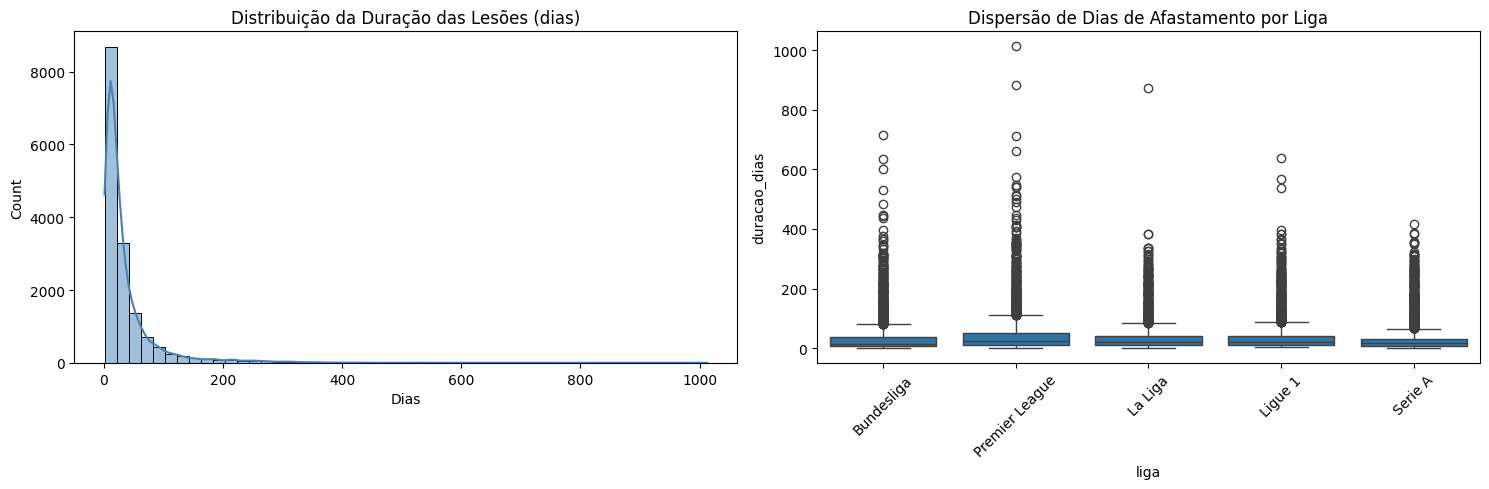

In [18]:
fig, axes = plt.subplots(1,2, figsize=(15, 5))

# Histograma de dias de afastamento
sns.histplot(df_injuries['duracao_dias'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição da Duração das Lesões (dias)')
axes[0].set_xlabel('Dias')

# Boxplot de dias por liga (Comparativo)
sns.boxplot(data=df_injuries, x='liga', y='duracao_dias', ax=axes[1])
axes[1].set_title("Dispersão de Dias de Afastamento por Liga")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 9) Distribuição Visual (Histogramas e Boxplots)

Para complementar a análise estatística descritiva, foram utilizados **histogramas** e **boxplots**, com o objetivo de representar visualmente a distribuição da variável `duracao_dias` e comparar seu comportamento entre as diferentes ligas europeias.

O **histograma da duração das lesões** evidencia uma distribuição fortemente assimétrica à direita. Observa-se uma grande concentração de casos em afastamentos curtos, especialmente nas primeiras faixas de dias, enquanto a frequência diminui rapidamente à medida que a duração aumenta. Esse comportamento confirma o que já havia sido identificado nas medidas de tendência central: a maior parte das lesões possui curta duração, mas há um número reduzido de casos extremamente longos que estendem a cauda da distribuição. Assim, trata-se de uma variável com forte presença de outliers e alta dispersão.

Já o **boxplot da duração das lesões por liga** permite comparar a distribuição dos afastamentos entre Bundesliga, Premier League, La Liga, Ligue 1 e Serie A. De modo geral, as medianas e os intervalos interquartis das ligas são relativamente semelhantes, sugerindo um comportamento central próximo entre os campeonatos. No entanto, todas as ligas apresentam quantidade expressiva de valores extremos, indicando que lesões graves ou afastamentos muito longos são um fenômeno recorrente em todo o futebol europeu, e não restrito a uma competição específica.

Além disso, nota-se que algumas ligas apresentam outliers mais elevados do que outras, como a Premier League e a La Liga, que exibem casos de afastamentos excepcionalmente longos. Isso sugere que, embora o padrão central seja semelhante, a severidade máxima das lesões pode variar entre as ligas.

Em conjunto, essas visualizações reforçam três pontos principais:
- a distribuição de `duracao_dias` não é normal, sendo marcada por forte assimetria positiva;
- a maioria das lesões é de curta duração;
- os casos extremos devem ser mantidos na base, pois representam eventos reais e relevantes para a compreensão da severidade das lesões.

Dessa forma, os gráficos confirmam que a variável `duracao_dias` exige atenção especial nas análises posteriores, sendo recomendável o uso de medidas robustas, como mediana e percentis, além de possíveis transformações ou segmentações em etapas preditivas futuras.

## 10) Análise de Relações (Correlação e Dispersão)

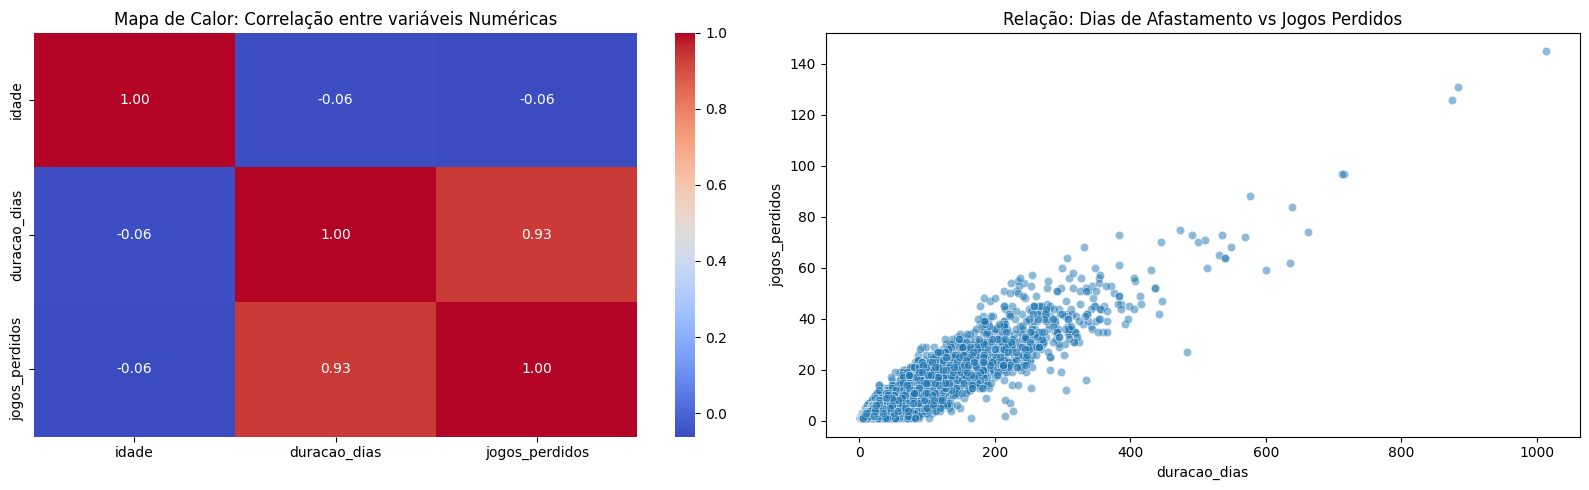

In [19]:
# Matriz de correlação e Gráfico de dispersão: Dias vs Jogos Perdidos
fig, axes = plt.subplots(1,2,figsize=(16,5))
corr = df_injuries[cols_num].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title("Mapa de Calor: Correlação entre variáveis Numéricas")

sns.scatterplot(data=df_injuries, x='duracao_dias', y='jogos_perdidos', alpha=0.5)
axes[1].set_title("Relação: Dias de Afastamento vs Jogos Perdidos")

plt.tight_layout()
plt.show()

### 10) Análise de Relações (Correlação e Dispersão)

Para investigar as relações existentes entre as variáveis numéricas do dataset, foram utilizados um **mapa de calor de correlação** e um **gráfico de dispersão**, técnicas complementares que permitem identificar tanto a intensidade quanto a forma das associações entre as variáveis.

O **mapa de calor** apresenta os coeficientes de correlação de Pearson entre `idade`, `duracao_dias` e `jogos_perdidos`. Os resultados revelam dois padrões distintos:

- A correlação entre `duracao_dias` e `jogos_perdidos` é de **0,93**, indicando uma associação positiva muito forte. Isso significa que, quanto maior o tempo de afastamento de um atleta, maior tende a ser o número de partidas que ele perde, o que é esperado e confirma a coerência interna dos dados.
- Já a correlação entre `idade` e as demais variáveis é de apenas **-0,06** em ambos os casos, valor próximo de zero que indica ausência de relação linear relevante. Isso sugere que a idade do atleta, isoladamente, não é um fator determinante para a gravidade ou duração de uma lesão neste dataset.

O **gráfico de dispersão** entre `duracao_dias` e `jogos_perdidos` confirma visualmente a forte correlação identificada. A nuvem de pontos apresenta uma tendência linear clara e crescente: atletas com afastamentos mais longos tendem a perder mais jogos de forma proporcional. Observa-se também que a dispersão aumenta conforme a duração cresce, o que indica maior variabilidade nos casos mais graves, possivelmente influenciada pelo calendário de cada liga ou pela fase da temporada em que a lesão ocorreu.

Alguns pontos extremos são visíveis no canto superior direito do gráfico, representando os casos mais severos do dataset, com afastamentos superiores a 600 dias e mais de 100 jogos perdidos. Esses casos, embora raros, reforçam a importância de considerar a severidade das lesões como uma dimensão crítica em análises preditivas futuras.

Em síntese, os resultados desta etapa indicam que:
- O **tempo de afastamento é o principal preditor do impacto esportivo** (jogos perdidos);
- A **idade não apresenta correlação linear** com a gravidade das lesões neste conjunto de dados;
- A relação entre `duracao_dias` e `jogos_perdidos` é robusta e consistente, validando ambas as variáveis como representações complementares da severidade de uma lesão.

## 11) Gráfico de Boxplot (Posição e Idade)

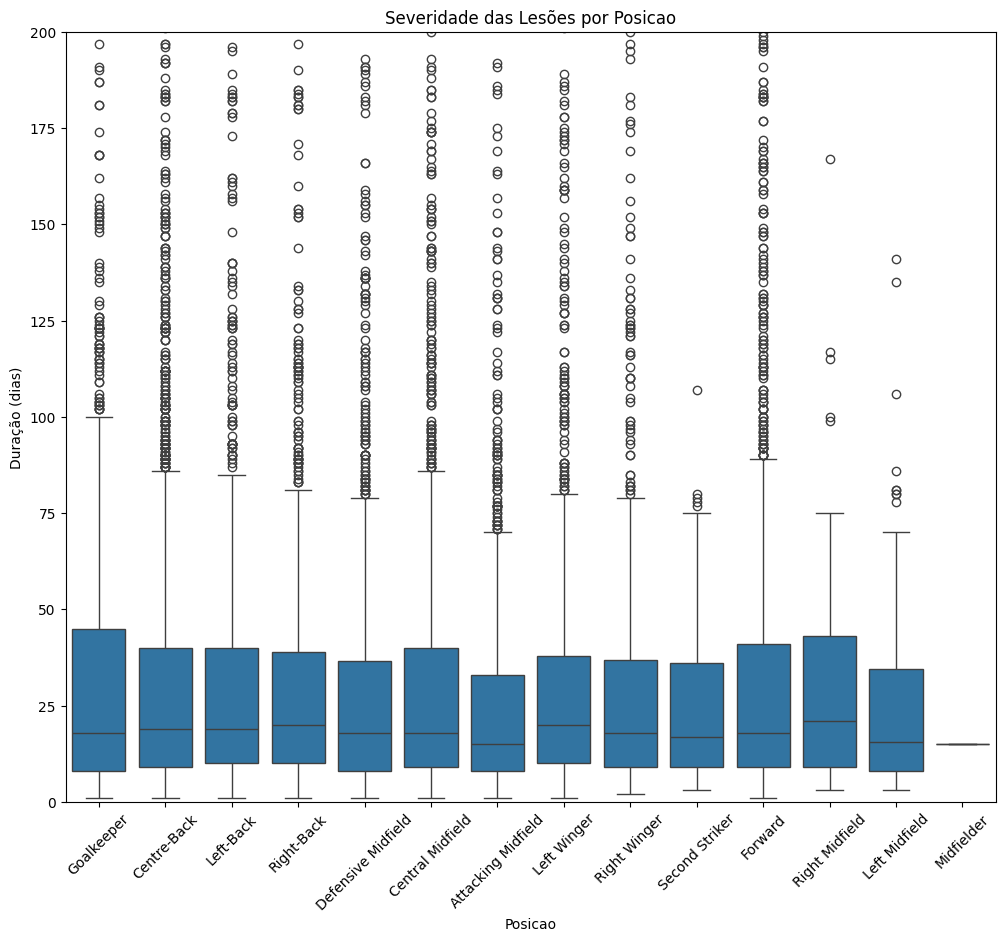

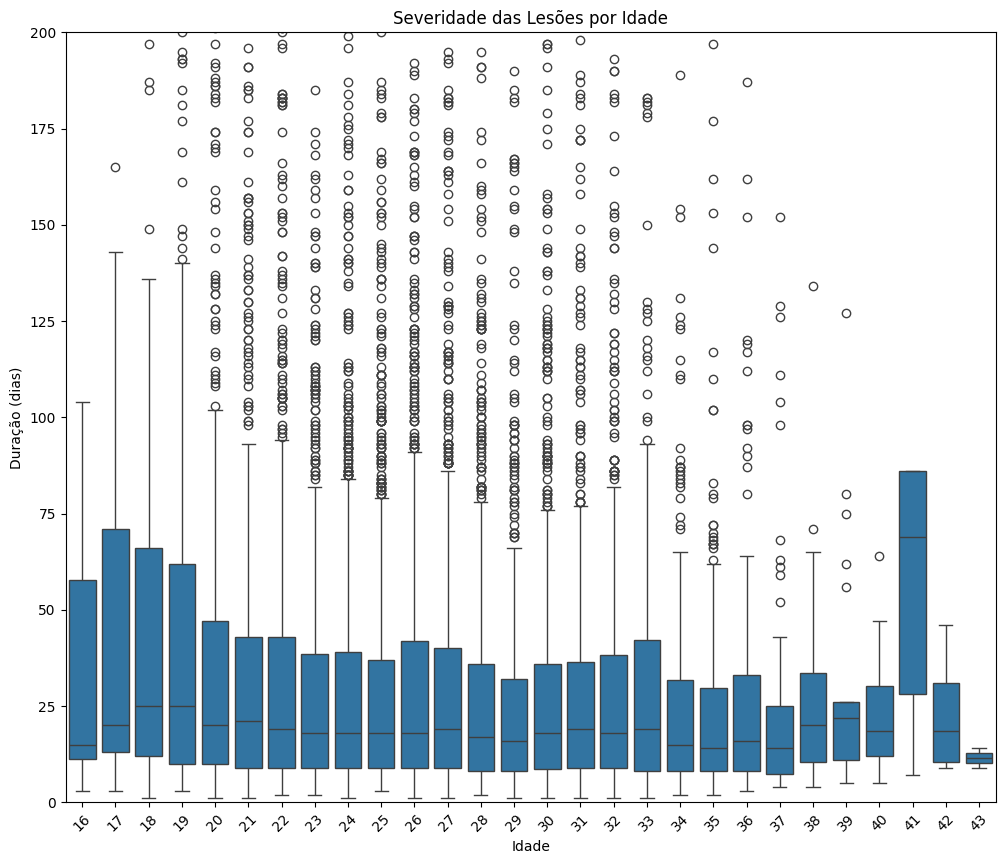

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

box_grafico = ['posicao', 'idade']

for var in box_grafico:
    plt.figure(figsize=(12, 10))
    sns.boxplot(data=df_injuries, x=var, y='duracao_dias')
    plt.ylim(0, 200)
    plt.title(f'Severidade das Lesões por {var.capitalize()}')
    plt.xlabel(var.capitalize())
    plt.xticks(rotation=45)
    plt.ylabel('Duração (dias)')
    plt.show()

### 1. Análise de Severidade das Lesões por Posição

A tabela abaixo descreve o comportamento da variável de duração da recuperação em relação à posição do atleta em campo.

| Posição | Observação sobre a Variável |
| :--- | :--- |
| **Goleiros (GK)** | Apresentam mediana próxima a 18 dias, com grande dispersão superior e presença de valores extremos (outliers) acima de 150 dias. |
| **Defensores (CB, LB, RB)** | Comportamento estatístico consistente entre as subcategorias, com quartis equilibrados e mediana em torno de 20 dias. |
| **Meio-campistas** | Maior concentração de dados em períodos curtos, porém é a categoria com o maior volume visual de outliers, indicando alta frequência de lesões. |
| **Atacantes (Forward)** | Apresentam o terceiro quartil mais elevado, sugerindo que as lesões nesta posição tendem a se estender por mais tempo que a média geral. |
| **Lados de Campo (RM/LM)** | Menor densidade de dados, mas com uma caixa (IQR) levemente deslocada para cima, indicando maior tempo de recuperação basal. |

#### Interpretação Prática
* **Predomínio de Lesões Leves:** Em todas as posições, a mediana de recuperação é inferior a 30 dias, o que aponta para uma maioria de lesões musculares de grau I ou contusões simples.
* **Severidade Universal:** Fora necessária a limitação para 200 dias dos Outliers de "dias de afastamento", pois os resultados mais extremos estavam afetando a visualização dos gráficos.

**Resumo:** O gráfico demonstra que a posição do jogador não é um fator determinante para a severidade média da lesão, dado que as medianas são similares. Contudo, a variabilidade e os valores extremos reforçam a necessidade de protocolos de fisioterapia personalizados para a alta demanda do futebol de elite.

---

### 2. Análise de Severidade das Lesões por Idade

Esta análise verifica como o fator biológico da idade influencia no tempo de recuperação dos atletas.

| Faixa Etária | Observação sobre a Variável |
| :--- | :--- |
| **16 a 20 anos** | Mediana baixa, evidenciando recuperação rápida, mas com "bigodes" longos indicando casos de lesões graves precoces. |
| **21 a 35 anos** | Estabilidade estatística notável. A mediana e a dispersão permanecem constantes, representando o platô de performance física. |
| **36 a 40 anos** | Início de um aumento na variabilidade. O intervalo interquartil (caixa) começa a se expandir, indicando maior incerteza no tempo de cura. |
| **41 anos ou mais** | Elevação visível da mediana e da base do boxplot, sugerindo que o tempo mínimo de recuperação aumenta com a idade avançada. |

#### Interpretação Prática
* **Resiliência no Auge:** Entre os 25 e 32 anos, o corpo do atleta profissional demonstra uma resposta padrão e previsível aos tratamentos médicos.
* **Severidade Universal:** Fora necessária a limitação para 200 dias dos Outliers de "dias de afastamento", pois os resultados mais extremos estavam afetando a visualização dos gráficos.

**Resumo:** Os dados confirmam a hipótese biológica de que a recuperação se torna mais lenta com o avançar da idade, especialmente após os 35 anos. Entretanto, a severidade extrema das lesões (outliers) parece ser um risco onipresente na carreira de um jogador de futebol, independente da sua idade.



# 12) VIF


In [21]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import tkinter as tk
from tkinter import filedialog

print("Aguarde... Uma janela do Windows vai abrir para voce escolher o arquivo!")

root = tk.Tk()
root.attributes('-topmost', True)
root.withdraw()

caminho_arquivo = filedialog.askopenfilename(
    title="Selecione o CSV ou o ZIP baixado",
    filetypes=[("Arquivos de Dados", "*.csv *.zip")]
)

if caminho_arquivo:
    df_meu = pd.read_csv(caminho_arquivo)
    
    df_meu['Days'] = df_meu['Days'].astype(str).str.extract(r'(\d+)')[0].astype(float)
    df_numerico = df_meu[['player_age', 'Games missed', 'Days']].dropna()

    X = sm.add_constant(df_numerico)
    vif_data = pd.DataFrame()
    vif_data["Variável"] = X.columns
    vif_data["Valor VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    vif_data = vif_data[vif_data["Variável"] != "const"].sort_values(by="Valor VIF", ascending=False)
    
    print("Sucesso Absoluto! Tabela VIF:")
    display(vif_data)
else:
    print("Cancelado. Rode a celula novamente se quiser tentar de novo.")

ModuleNotFoundError: No module named 'statsmodels'

    
Variável	Valor VIF : 
2	Games missed	7.900509 /
3	Days	7.895692 /
1	player_age	1.003847


📊 Análise de Multicolinearidade (VIF)
Durante a preparação dos dados para a Análise Preditiva, foi realizado o cálculo do VIF (Variance Inflation Factor) para identificar possíveis problemas de multicolinearidade entre as variáveis numéricas do conjunto de dados.

🔍 Resultados Obtidos:
🚨 Games missed (7.90) e Days (7.89): Ambas apresentaram valores superiores a 5. Isso comprova matematicamente uma forte multicolinearidade, o que faz sentido no contexto do esporte: o tempo de afastamento em dias afeta diretamente e de forma proporcional a quantidade de partidas perdidas pelo jogador.
✅ player_age (1.00): O VIF próximo de 1 indica ausência de colinearidade, mostrando que a idade do jogador é uma variável independente sólida em relação ao tempo de afastamento.
💡 Conclusão e Recomendação para a Modelagem:
Ação: Devemos evitar o uso simultâneo de Games missed e Days como variáveis independentes no mesmo modelo de Machine Learning. Para não inflar a variância, causar viés e prejudicar as previsões, recomenda-se selecionar apenas uma dessas variáveis de impacto para treinar o algoritmo na próxima etapa.

# 13) EDA Parte 2

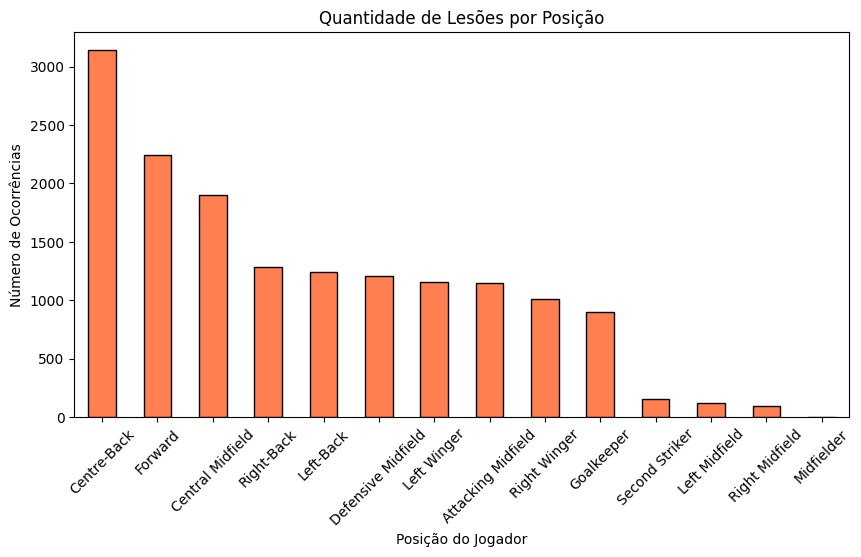

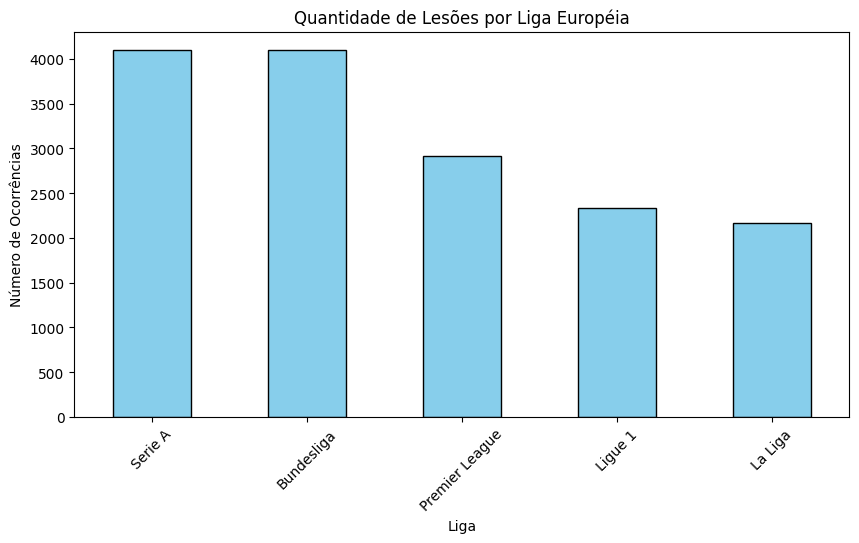


🚨 ANTES DA CODIFICAÇÃO (Texto original):


,player_position,league
0,Goalkeeper,Bundesliga
1,Goalkeeper,Bundesliga
2,Centre-Back,Bundesliga



✅ DEPOIS DA CODIFICAÇÃO (Números prontos para o modelo Preditivo):


,player_position_Central Midfield,player_position_Centre-Back,player_position_Defensive Midfield,player_position_Forward,player_position_Goalkeeper,player_position_Left Midfield,player_position_Left Winger,player_position_Left-Back,player_position_Midfielder,player_position_Right Midfield,player_position_Right Winger,player_position_Right-Back,player_position_Second Striker,league_La Liga,league_Ligue 1,league_Premier League,league_Serie A
0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --- PARTE 1: Os Gráficos ---
# Gráfico: Quantidade de lesões por Posição do jogador
plt.figure(figsize=(10, 5))
df_injuries['player_position'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Quantidade de Lesões por Posição')
plt.xlabel('Posição do Jogador')
plt.ylabel('Número de Ocorrências')
plt.xticks(rotation=45)
plt.show()

# Gráfico: Quantidade de lesões por Liga
plt.figure(figsize=(10, 5))
df_injuries['league'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Quantidade de Lesões por Liga Européia')
plt.xlabel('Liga')
plt.ylabel('Número de Ocorrências')
plt.xticks(rotation=45)
plt.show()

# --- PARTE 2: A Codificação (Transformando texto em número para a IA) ---
print("\n🚨 ANTES DA CODIFICAÇÃO (Texto original):")
display(df_injuries[['player_position', 'league']].head(3))

# O comando get_dummies transforma as categorias em colunas de 0 e 1
df_codificado = pd.get_dummies(df_injuries, columns=['player_position', 'league'], drop_first=True)

print("\n✅ DEPOIS DA CODIFICAÇÃO (Números prontos para o modelo Preditivo):")
# Mostrando apenas as novas colunas numéricas criadas para você ver a diferença
colunas_novas = [col for col in df_codificado.columns if 'player_position_' in col or 'league_' in col]
display(df_codificado[colunas_novas].head(3))

Nesta etapa, focamos na preparação das variáveis categóricas e na visualização da distribuição de lesões para subsidiar o modelo preditivo.

1. Distribuição de Lesões por Posição e Liga
Foram gerados gráficos de barras para identificar padrões de incidência:

Posição: Analisamos quais setores do campo (Goleiros, Defensores, Meias ou Atacantes) sofrem mais afastamentos.
Ligas: Comparação do volume de dados entre as cinco grandes ligas europeias (Bundesliga, Premier League, La Liga, Ligue 1 e Serie A).


2. Codificação de Variáveis (Feature Engineering)
Como modelos de Machine Learning (como o Random Forest) operam apenas com dados numéricos, aplicamos a técnica de One-Hot Encoding utilizando a função get_dummies.

O que foi feito: As colunas de texto player_position e league foram transformadas em vetores binários (True/False).
Resultado: O dataset agora possui colunas específicas para cada categoria, permitindo que o algoritmo calcule pesos matemáticos para cada posição e liga sem criar uma hierarquia falsa entre elas.


3. Validação Final para Modelagem
Com as variáveis numéricas validadas pelo VIF e as categóricas devidamente codificadas, o dataset está pronto para a fase de Treinamento e Teste, garantindo que:

Não há redundância de dados (Multicolinearidade controlada).
Todas as informações táticas e de contexto estão em formato legível para a IA.

# 14) Previsão do Tipo de Lesão

Nesse momento faremos uma previsão a respeito de qual lesão é esperada utilizando a coluna Injury como alvo.

## 14.1) Definição do problema de previsão

Nesta etapa, o objetivo é prever o tipo de lesão do jogador a partir de variáveis de contexto e perfil.

- **Variável-alvo:** `tipo_lesao` (originalmente `Injury`)
- **Variáveis de entrada:** `idade`, `posicao`, `clube`, `liga` e `temporada`

Antes da modelagem, será analisada a distribuição das classes da variável-alvo por meio de um gráfico de barras, para verificar desbalanceamento entre os tipos de lesão.

## 14.2) Preparação dos dados:

In [ ]:
df_model = df_injuries.copy()

# Padronização da variável-alvo
df_model['tipo_lesao'] = df_model['tipo_lesao'].astype(str).str.strip().str.lower()

# Seleção das variáveis que entram no modelo
X_base = df_model[['idade', 'posicao', 'clube', 'liga', 'temporada']].copy()
y_base = df_model['tipo_lesao'].copy()

## 14.3) Grafico de barras (Barplot)

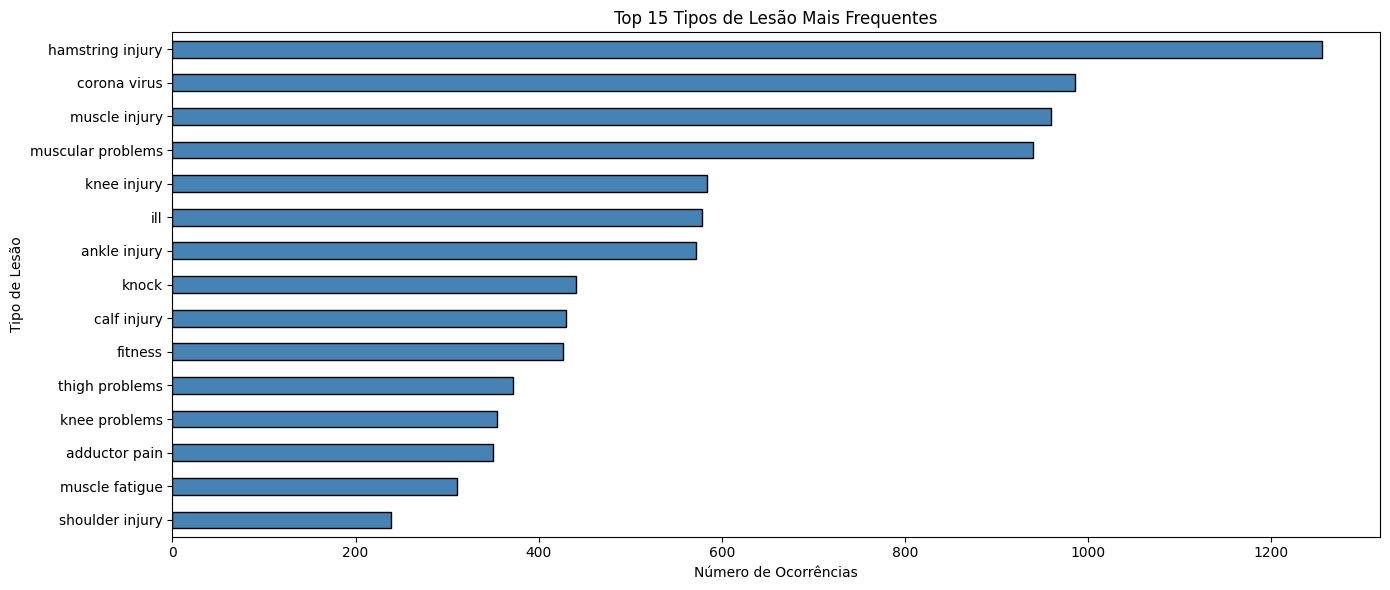

In [ ]:
plt.figure(figsize=(14, 6))

ordem_lesoes = y_base.value_counts().head(15)
ordem_lesoes.sort_values(ascending=True).plot(kind='barh', color='steelblue', edgecolor='black')

plt.title('Top 15 Tipos de Lesão Mais Frequentes')
plt.xlabel('Número de Ocorrências')
plt.ylabel('Tipo de Lesão')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Codificação do alvo
le = LabelEncoder()
y = le.fit_transform(y_base)

# Codificação das variáveis de entrada
X = pd.get_dummies(
    X_base,
    columns=['posicao', 'clube', 'liga', 'temporada'],
    drop_first=True
)

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 14.4 TReinamento do modelo

In [ ]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(
    max_iter=2000,
    multi_class='multinomial'
)

modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

print("Acurácia:", accuracy_score(y_test, y_pred))
print("F1 Macro:", f1_score(y_test, y_pred, average='macro'))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

## 14.5) Matriz de confusão

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(16, 12))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=le.classes_,
    xticks_rotation=90,
    cmap='Blues',
    colorbar=False
)
plt.title('Matriz de Confusão - Previsão do Tipo de Lesão')
plt.tight_layout()
plt.show()

## 14.6) Conclusão da previsão

A previsão do tipo de lesão foi estruturada como um problema de classificação multiclasse. O gráfico de barras da variável-alvo permitiu observar a distribuição das categorias e verificar se há concentração excessiva em alguns tipos de lesão.

A partir dos resultados obtidos, será possível avaliar:
- o comportamento do modelo em classes mais frequentes;
- a dificuldade de previsão em classes menos representadas;
- a necessidade de ajustes futuros, como tratamento de classes raras ou teste de outros algoritmos.


## 15) Relações entre Variáveis Numéricas com Pairplot Balanceado (idade, duração das lesões e jogos perdidos por liga)

A proposta desta seção é avaliar a relação entre as três variáris numéricas: idades dos jogadores, tempo de lesão (em dias) e número de jogos peridos. Além disso, buscamos comparar esses padrões entre as diferentes ligas europeias analisadas.

Para garantir uma comparação justa entre as ligas, foi selecionada uma amostragem que inclui 100 registros para cada liga. Também foi realizado um filtro para remover lesões que possuem duração supeerior a 200 dias, com o objetico de reduzir o impacto de valroes extremos.

O parâmetro "random_state=42" do código foi utilizado para garantir que os mesmos registros sejam selecionados a cada execução do código.

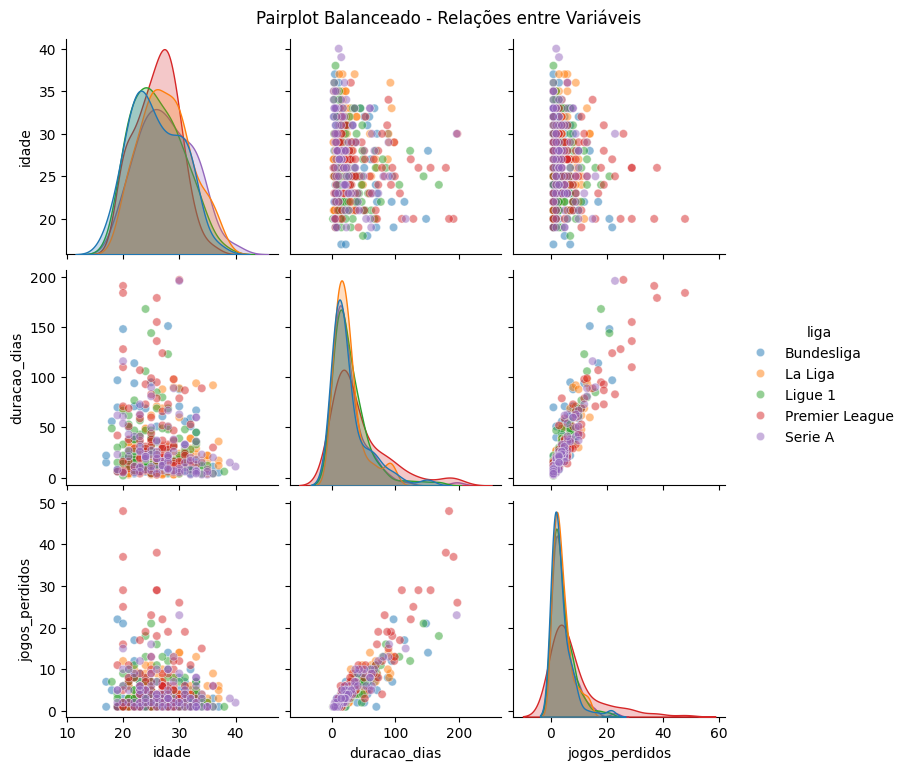

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['idade', 'duracao_dias', 'jogos_perdidos']
df_balanced = df_injuries.groupby('liga').sample(n=100, random_state=42)
df_balanced = df_balanced[df_balanced['duracao_dias'] < 200]

sns.pairplot(
    df_balanced[cols + ['liga']],
    hue='liga',
    diag_kind='kde',
    plot_kws={'alpha': 0.5}
)

plt.suptitle("Pairplot Balanceado - Relações entre Variáveis", y=1.02)
plt.show()

### 15.1 Análise dos resultados obtidos

A partir dos resultados obtidos, foi possível avaliar:

- duracao_dias × jogos_perdidos: 
O gráfico que analisa a duração das lesões e jogos perdidos apresenta uma clara tendência crescente, indicando uma forte relação positiva entre as variáveis. Quanto maior o tempo de afastamento, maior o número de partidas perdidas. Essa relação valida a coerência dos dados e confirma que a duração da lesão é um bom indicador do impacto esportivo.

- idade × jogos_perdidos:
O gráfico que relaciona a idade dos jogadores com o número de jogos perdidos apresenta uma distribuição dispersa, sem formação de padrão evidente. Esse comportamento indica que a idade não exerce influência significativa sobre o impacto da lesão em termos de partidas não disputadas.

- distribuição da idade:
O gráfico de distribuição da variável idade apresenta formato aproximadamente simétrico, com maior concentração entre 20 e 30 anos em todas as ligas. Isso indica que a maioria dos jogadores lesionados está em uma faixa etária típica do auge da carreira, sem grande presença de valores extremos.

-  distribuição de duracao_dias:
O gráfico de distribuição da duração das lesões em dias apresenta forte assimetria à direita, com grande concentração de casos de curta duração e poucos casos de longa duração. Esse comportamento indica que lesões graves são menos frequentes, porém impactantes.

-  distribuição de jogos_perdidos:
O gráfico de distribuição dos jogos perdidos também apresenta assimetria, com predominância de valores baixos e poucos casos extremos. Isso indica que a maioria das lesões resulta em poucos jogos perdidos, enquanto alguns eventos mais severos geram impactos maiores.

-  comparação entre ligas:
A análise comparativa entre as ligas, representadas por cores no gráfico, não evidencia separação clara entre os grupos. As distribuições e relações entre as variáveis são semelhantes entre as ligas, sugerindo um comportamento homogêneo das lesões no futebol europeu.


Conclusão: 

O conjunto de gráficos evidencia que a duração da lesão é o principal fator associado ao número de jogos perdidos, apresentando uma forte relação positiva. Por outro lado, a idade não demonstra influência significativa sobre a gravidade ou o impacto das lesões. Além disso, observa-se que a maioria das lesões é de curta duração e baixo impacto, embora existam casos extremos. As ligas europeias apresentam comportamento semelhante, sem diferenças relevantes entre elas.